## Data

### Real Data

In [1]:
from simulator_simple import SpectrumSimple
import torch

parameters_range={"x0": [450, 500],"x1": [0, 1.5], "x2": [450, 500], "x3": [0, 1.5]}
output_names = ["desorption"]

n_weights = 50
exp_times = torch.linspace(450, 500, n_weights)

simulator = SpectrumSimple(parameters_range, output_names, times=exp_times)


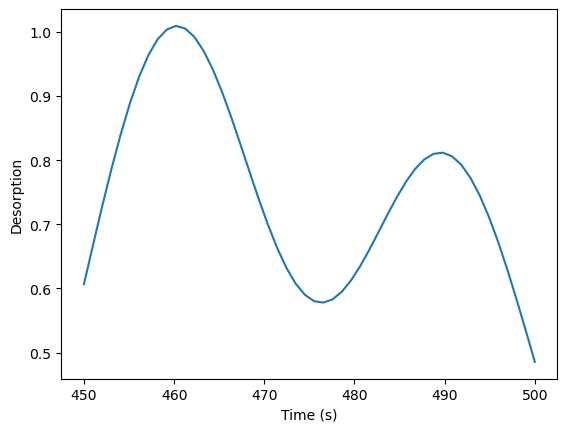

In [2]:
import matplotlib.pyplot as plt


true_parameters = torch.Tensor([[460, 1, 490, 0.8]])

observation = simulator.forward(true_parameters, allow_failures=False)
plt.plot(simulator.times, observation.T)
plt.xlabel("Time (s)")
plt.ylabel("Desorption")
plt.show()

### Training data

In [3]:
n_samples = 100

X = simulator.sample_inputs(n_samples)

X.shape

torch.Size([100, 4])

In [4]:
Y, _ = simulator.forward_batch(X)
Y.shape

torch.Size([100, 50])

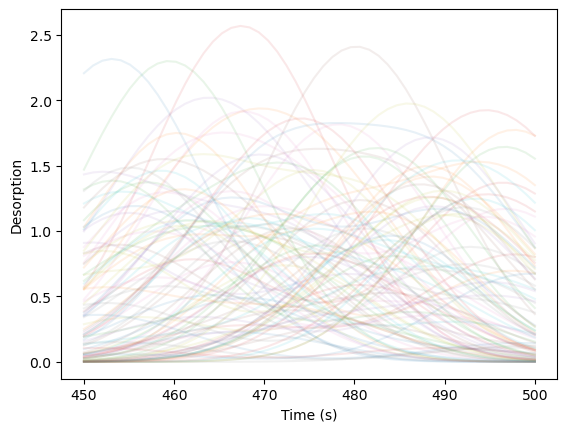

In [5]:
plt.plot(simulator.times, Y.T, alpha=0.1)
plt.xlabel("Time (s)")
plt.ylabel("Desorption")
plt.show()

## Build emulator

In [6]:
from autoemulate import AutoEmulate

AutoEmulate.list_emulators()

,Emulator,PyTorch,Multioutput,Uncertainty_Quantification,Automatic_Differentiation
0,GaussianProcessMatern32,True,True,True,True
1,GaussianProcessRBF,True,True,True,True
2,RadialBasisFunctions,True,True,False,True
3,PolynomialRegression,True,True,False,True
4,MLP,True,True,False,True
5,EnsembleMLP,True,True,True,True


In [24]:
from autoemulate.core.compare import AutoEmulate
from autoemulate.transforms import StandardizeTransform, PCATransform
import torch
import numpy as np


# Convert to tensors
x, y = torch.Tensor(X).float(), torch.Tensor(Y).float()

# Split into train/test data
test_idx = [np.array([13, 39, 30, 45, 17, 48, 26, 25, 32, 19])]
train_idx = np.setdiff1d(np.arange(len(x)), test_idx)

# Run AutoEmulate
ae = AutoEmulate(
    x[train_idx], 
    y[train_idx],
    models=["GaussianProcessRBF"],
    x_transforms_list=[[StandardizeTransform()]],
    y_transforms_list=[[
        PCATransform(n_components=8),
        StandardizeTransform()
    ]],
    # fewer bootstraps to reduce computation time, though more uncertainty on test score
    n_bootstraps=None,
    log_level="error",
    model_params={"posterior_predictive": True},
    transformed_emulator_params={
        "full_covariance": False,
        "output_from_samples": False
    }
)

In [25]:
ae.summarise().T

,0
model_name,GaussianProcessRBF
x_transforms,[StandardizeTransform()]
y_transforms,"[PCATransform(), StandardizeTransform()]"
params,{'likelihood_cls': <class 'gpytorch.likelihood...
r2_test,0.986539
r2_test_std,NaN
rmse_test,0.04394
rmse_test_std,NaN
r2_train,0.998364
r2_train_std,NaN


In [26]:
em = ae.fit_from_reinitialized(x[train_idx], y[train_idx])

## Test predictions

In [27]:
# Get predictions for the full dataset
y_true = y[test_idx].numpy()
y_pred_dis = em.predict(x[test_idx])
y_pred, y_var_pred = em.predict_mean_and_variance(x[test_idx])

y_pred, y_std_pred = y_pred.numpy(), y_var_pred.sqrt().numpy()
print("Prediction distribution shape:", y_pred.shape, y_std_pred.shape)
print("Mean shape:", y_pred.shape)
print("Std shape:", y_std_pred.shape)

Prediction distribution shape: (10, 50) (10, 50)
Mean shape: (10, 50)
Std shape: (10, 50)


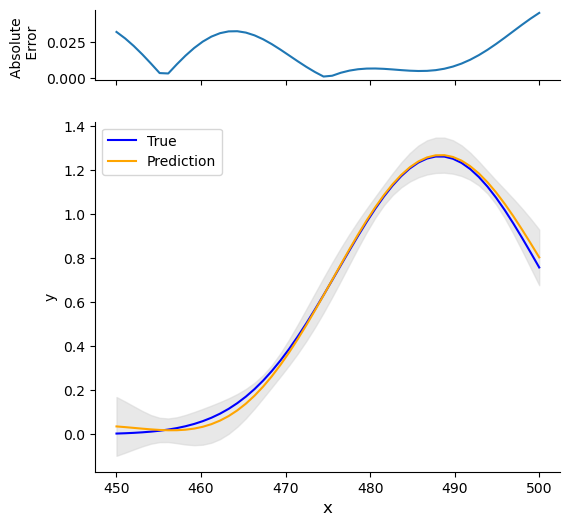

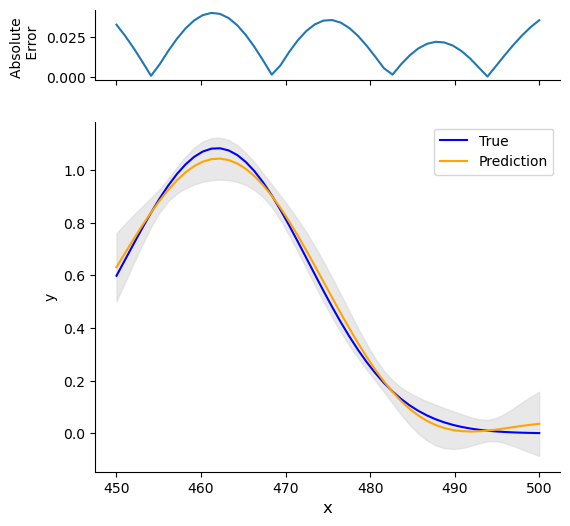

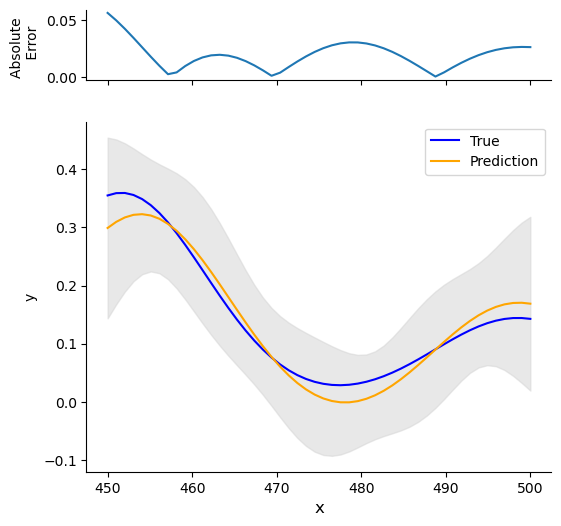

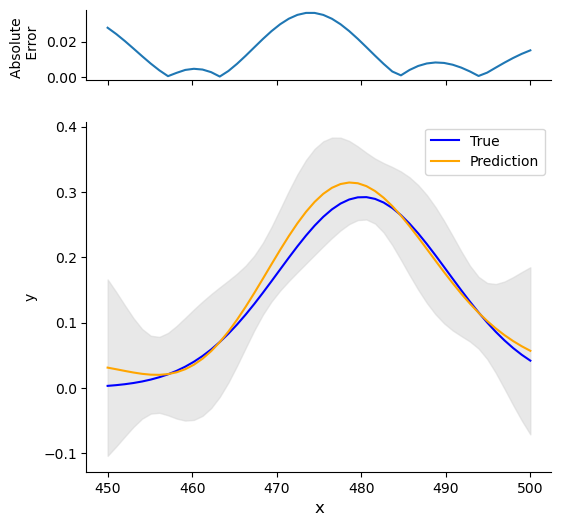

In [28]:
# Plot the results for some unseen (test) parameter instances
params_test = [0,1,2,3]

for param_test in params_test:
#   plt.figure(figsize=(20,4.5))
  fig, axs = plt.subplots(2, 1, figsize=(6, 6), sharex=True, gridspec_kw={'height_ratios': [0.2, 1]})
  plt.sca(axs[1])
  plt.plot(simulator.times, y_true[param_test], label='True', color='blue')

  plt.plot(simulator.times, y_pred[param_test], label='Prediction', color='orange')
  plt.fill_between(simulator.times,
                   y_pred[param_test]-2*y_std_pred[param_test],
                   y_pred[param_test]+2*y_std_pred[param_test],
                   color='lightgray', alpha=0.5)
  plt.ylabel('y')
  plt.xlabel('x', fontsize=12)
  plt.legend()

  plt.sca(axs[0])
  plt.plot(simulator.times, np.abs(y_pred[param_test] - y_true[param_test]))
  plt.ylabel('Absolute \n Error')
  # remove spines
  for ax in axs:
      ax.spines['top'].set_visible(False)
      ax.spines['right'].set_visible(False)
  plt.show()

## Saving the emulator

In [21]:
# Make a directory to save Emulator models
import os
path = "my_emulators"
if not os.path.exists(path):
    os.makedirs(path)

# The use_timestamp paramater ensures a new result is saved each time the save method is called
result_filepath = ae.save(em, path, use_timestamp=True)
print("Model and metadata saved to: ", result_filepath)

Model and metadata saved to:  my_emulators/GaussianProcessRBF_20260116_163803.joblib


## Bayesian calibration

In [22]:
from autoemulate.calibration.bayes import BayesianCalibration


bc = BayesianCalibration(
    em.model,
    parameter_range=parameters_range, 
    observations={"desorption": observation[0]}, 
    # specify noise as variance
    observation_noise=0.1**2
)

In [23]:
mcmc_emu = bc.run_mcmc(
    warmup_steps=100, 
    num_samples=1000,
    num_chains=2
)

Warmup [1]:   0%|          | 0/1100 [00:00, ?it/s]

Warmup [2]:   0%|          | 0/1100 [00:00, ?it/s]

/home/remidm/miniconda3/envs/festim-emulate/lib/python3.12/site-packages/torch/utils/_device.py:103: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)
/home/remidm/miniconda3/envs/festim-emulate/lib/python3.12/site-packages/torch/utils/_device.py:103: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


KeyboardInterrupt: 

In [ ]:
mcmc_emu.summary()

print(true_parameters)


                mean       std    median      5.0%     95.0%     n_eff     r_hat
        x0    475.14     14.19    474.72    450.83    495.24   2299.40      1.00
        x1      0.74      0.44      0.73      0.05      1.40   1888.65      1.00
        x2    475.03     14.52    474.83    453.17    497.87   2210.17      1.00
        x3      0.74      0.44      0.73      0.03      1.38   2146.31      1.00

Number of divergences: 0
tensor([[460.0000,   1.0000, 490.0000,   0.8000]])
